In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carregando o dataset
df = pd.read_csv('ncr_ride_bookings.csv')

### Reconhecendo os dados

In [36]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  str    
 1   Time                               150000 non-null  str    
 2   Booking ID                         150000 non-null  str    
 3   Booking Status                     150000 non-null  str    
 4   Customer ID                        150000 non-null  str    
 5   Vehicle Type                       150000 non-null  str    
 6   Pickup Location                    150000 non-null  str    
 7   Drop Location                      150000 non-null  str    
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  10500 non-null 

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


### Limpando e preparando os dados para análise

In [37]:
df.drop_duplicates(inplace=True)

df.isna().sum()

print(df['Vehicle Type'].value_counts())



Vehicle Type
Auto             37419
Go Mini          29806
Go Sedan         27141
Bike             22517
Premier Sedan    18111
eBike            10557
Uber XL           4449
Name: count, dtype: int64


Estou interessado em buscar padrões relativos a preços por hora do dia e distância, por isso vamos extrair data e hora do dataframe e criar a coluna 'Hour' para representar essas informações temporais.

In [38]:
df['Date'] = pd.to_datetime(df['Date'])
time_temp = pd.to_datetime(df['Time'], format='%H:%M:%S')
df['Hour'] = time_temp.dt.hour
df['Time'] = time_temp.dt.time

Apesar da expressiva quantidade de registros ausentes nas colunas de distância e preço da corrida, optei por eliminar essas linhas do dataset ao invés de preenchê-los com a média ou mediana, para evitar distorções na análise. Isso garante que cada ponto na análise de preço e distância seja baseado em dados reais, mesmo que reduzindo o total de registros disponíveis na amostragem (que permanece superior a 100.000).

In [39]:
df = df[df['Booking Value'].notna()]
df = df[df['Ride Distance'].notna()]

df.info()

<class 'pandas.DataFrame'>
Index: 102000 entries, 1 to 149999
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   Date                               102000 non-null  datetime64[us]
 1   Time                               102000 non-null  object        
 2   Booking ID                         102000 non-null  str           
 3   Booking Status                     102000 non-null  str           
 4   Customer ID                        102000 non-null  str           
 5   Vehicle Type                       102000 non-null  str           
 6   Pickup Location                    102000 non-null  str           
 7   Drop Location                      102000 non-null  str           
 8   Avg VTAT                           102000 non-null  float64       
 9   Avg CTAT                           102000 non-null  float64       
 10  Cancelled Rides by Customer        0

## Análise exploratória dos dados

#### Preço da corrida por distância:

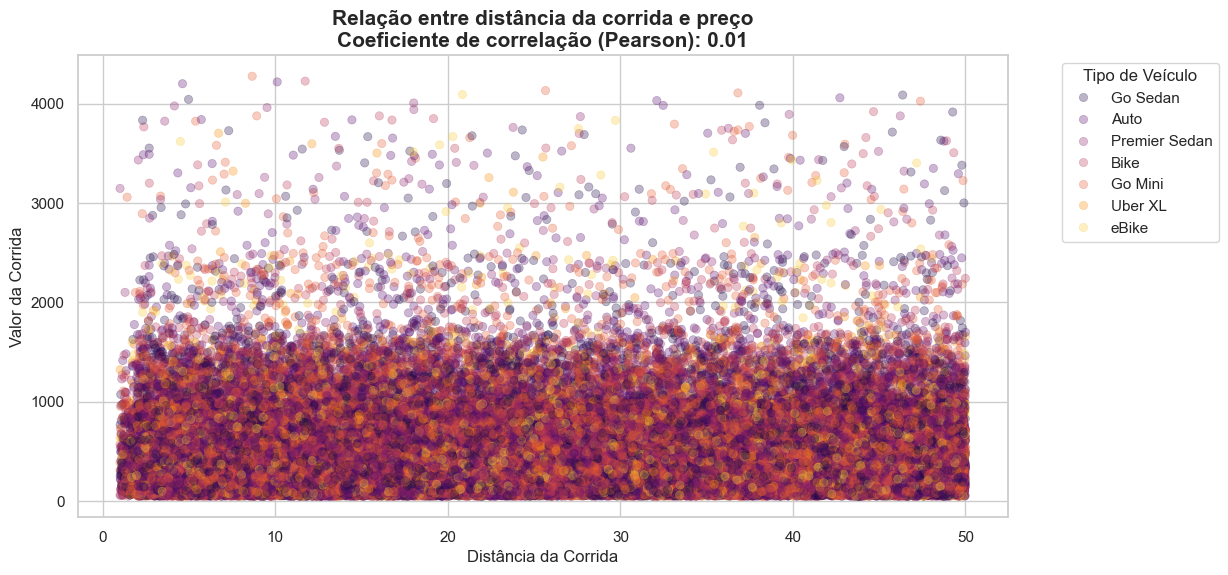

In [40]:
corr = df['Ride Distance'].corr(df['Booking Value'], method='pearson')

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

scatter = sns.scatterplot(
    data=df, 
    x='Ride Distance', 
    y='Booking Value', 
    hue='Vehicle Type',
    alpha=0.3, 
    palette='inferno',
    edgecolor=None
)

plt.title(f'Relação entre distância da corrida e preço\nCoeficiente de correlação (Pearson): {corr:.2f}', 
          fontsize=15, fontweight='bold')
    
plt.xlabel('Distância da Corrida', fontsize=12)
plt.ylabel('Valor da Corrida', fontsize=12)

plt.legend(title='Tipo de Veículo', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

#### Quantidade de corridas por hora do dia:

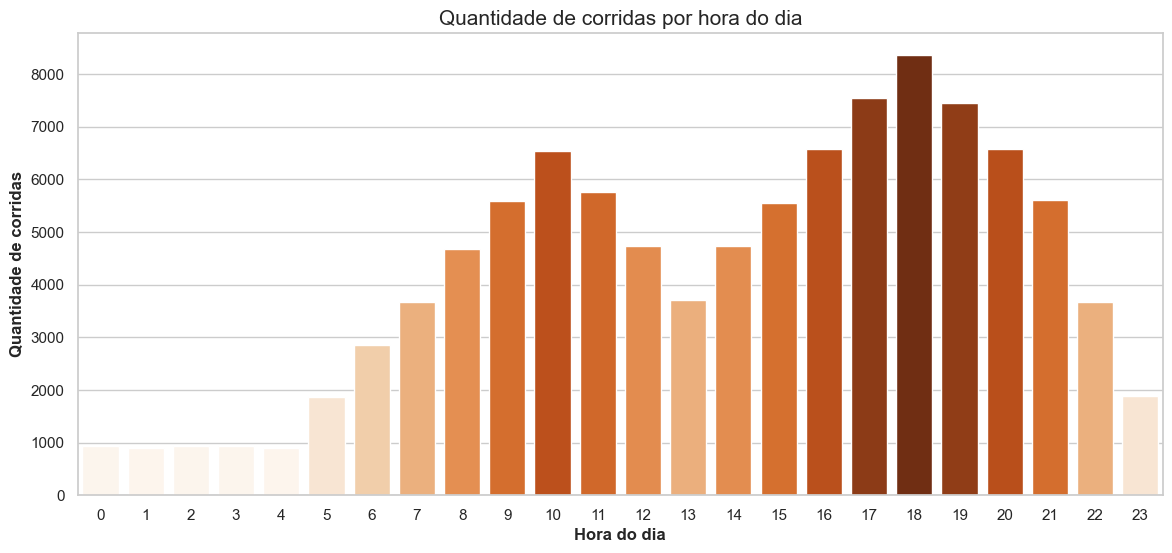

In [41]:
rides_by_hour = df['Hour'].value_counts().sort_index()

norm = plt.Normalize(rides_by_hour.min(), rides_by_hour.max())
colors = plt.cm.Oranges(norm(rides_by_hour.values)).tolist()

fig, ax = plt.subplots(figsize=(14,6))
sns.barplot(x=rides_by_hour.index,
            y=rides_by_hour.values,
            palette=colors,
            hue=rides_by_hour.index,
            legend=False,
            ax=ax)

ax.set_title('Quantidade de corridas por hora do dia', fontsize=15)
ax.set_xlabel('Hora do dia', fontweight='bold')
ax.set_ylabel('Quantidade de corridas', fontweight='bold')
ax.set_xticks(range(24))
plt.show()

#### Preço médio da corrida por hora do dia:

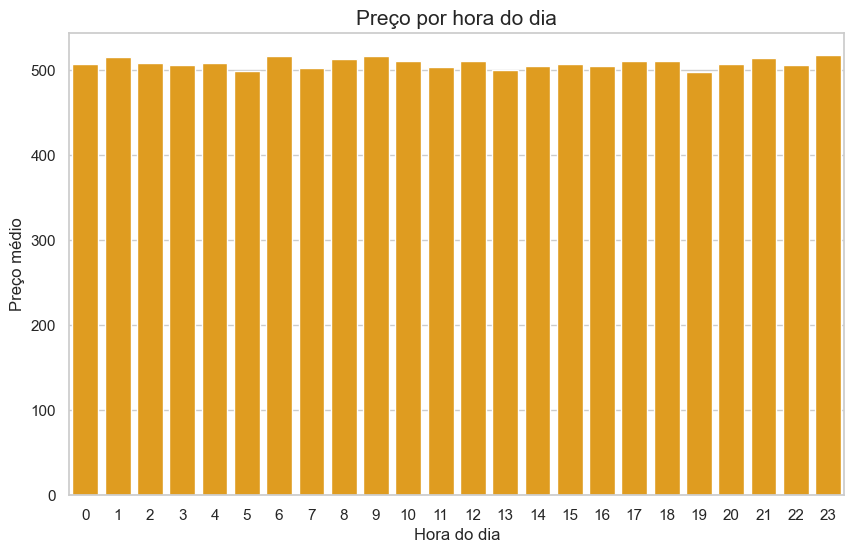

In [42]:
mean_price_by_hour = df.groupby('Hour')['Booking Value'].mean()

fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(x=mean_price_by_hour.index,
            y=mean_price_by_hour.values,
            color='orange',
            ax=ax)

ax.set_title('Preço por hora do dia', fontsize=15)
ax.set_xlabel('Hora do dia')
ax.set_ylabel('Preço médio')
ax.set_xticks(range(24))
plt.show()

#### Preço médio da corrida por dia da semana:

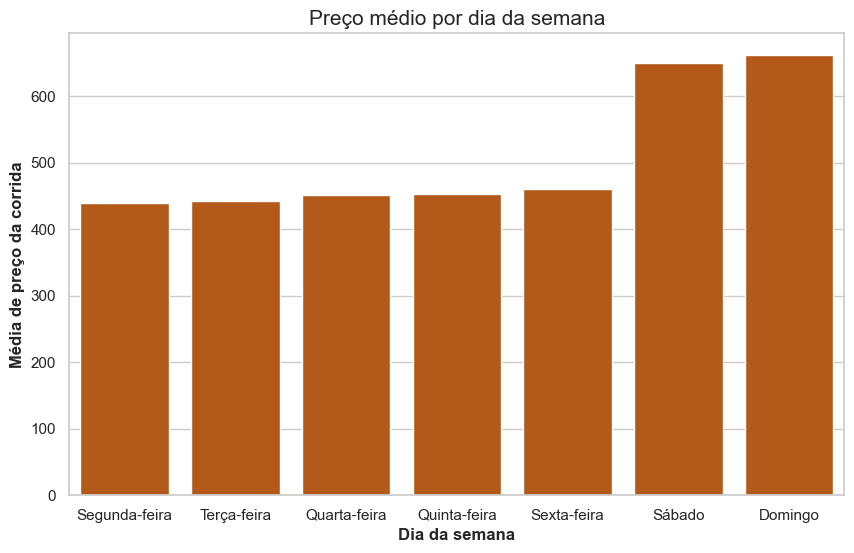

In [51]:
df['DayOfWeek'] = df['Date'].dt.day_name()

days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
days_ptbr = ["Segunda-feira", "Terça-feira", "Quarta-feira", "Quinta-feira", "Sexta-feira", "Sábado", "Domingo"]

df['DayOfWeek'] = pd.Categorical(df['DayOfWeek'], categories=days_order, ordered=True)

mean_price_by_day_of_week = df.groupby('DayOfWeek')['Booking Value'].mean()

fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(x=mean_price_by_day_of_week.index,
            y=mean_price_by_day_of_week.values,
            color="#CC5500",
            ax=ax)
ax.set_title("Preço médio por dia da semana", fontsize=15)
ax.set_xlabel("Dia da semana", fontweight='bold')
ax.set_ylabel("Média de preço da corrida", fontweight='bold')
ax.set_xticks(range(7))
ax.set_xticklabels(days_ptbr)
plt.show()

#### Quantidade de corridas por dia da semana:

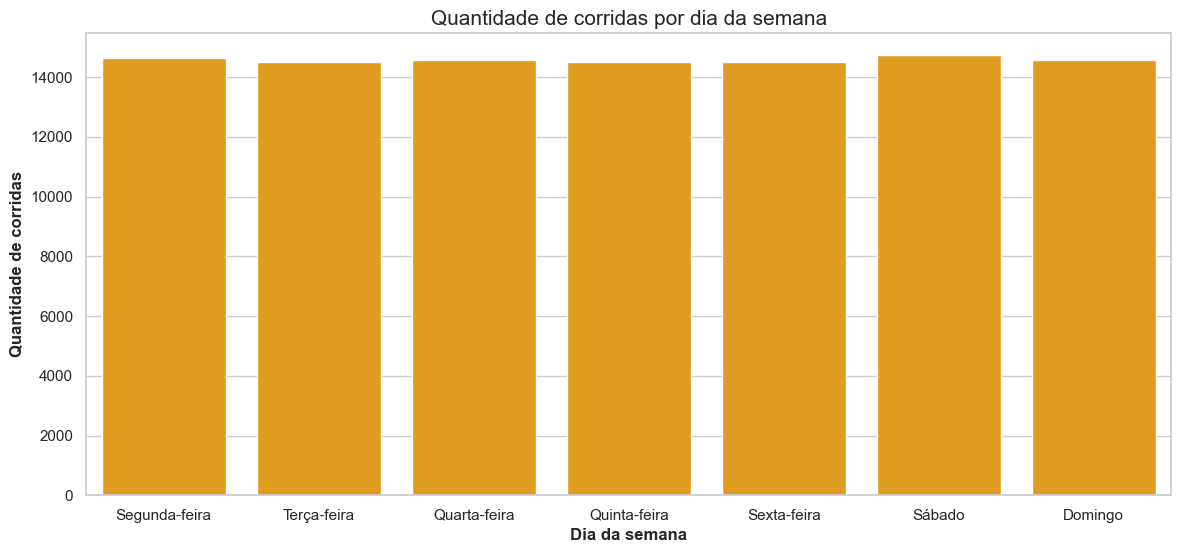

In [44]:
rides_by_day_of_week = df['DayOfWeek'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(14,6))
sns.barplot(x=rides_by_day_of_week.index,
            y=rides_by_day_of_week.values,
            color="orange",
            ax=ax)

ax.set_title('Quantidade de corridas por dia da semana', fontsize=15)
ax.set_xlabel('Dia da semana', fontweight='bold')
ax.set_ylabel('Quantidade de corridas', fontweight='bold')
ax.set_xticks(range(7))
ax.set_xticklabels(days_ptbr)
plt.show()

#### Mapa de calor de correlação entre variáveis numéricas:

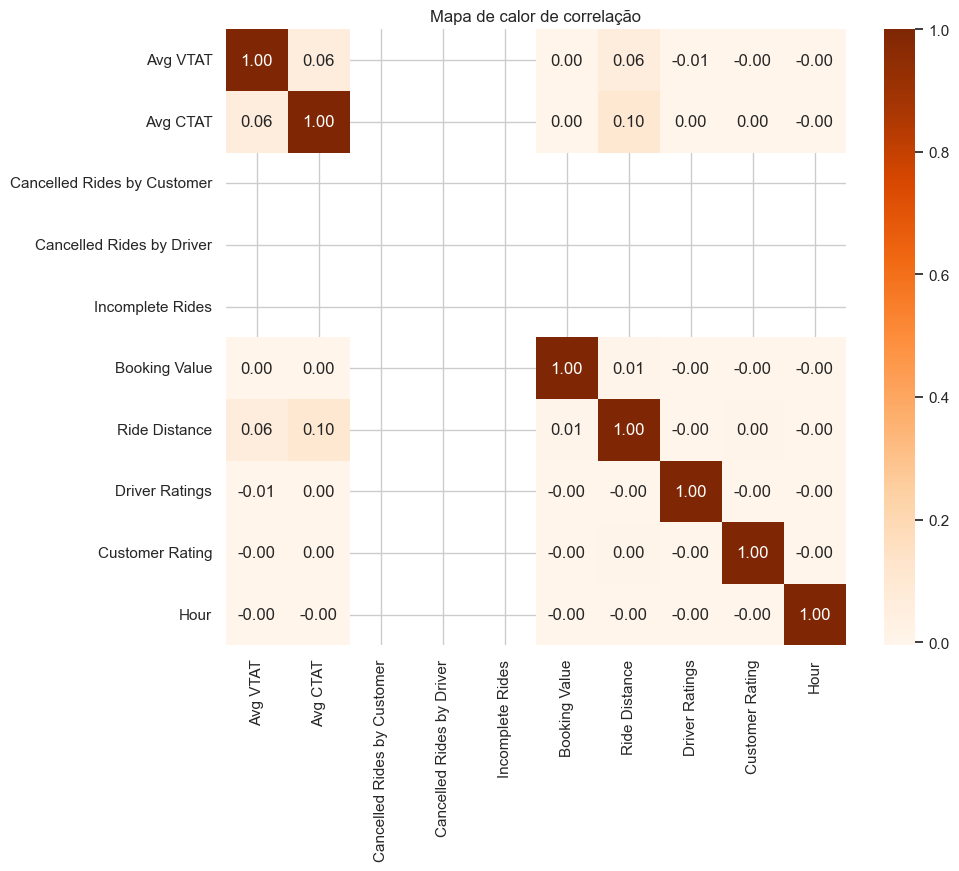

In [45]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="Oranges", fmt=".2f")
plt.title("Mapa de calor de correlação")
plt.show()

#### Preço e categoria de corrida:

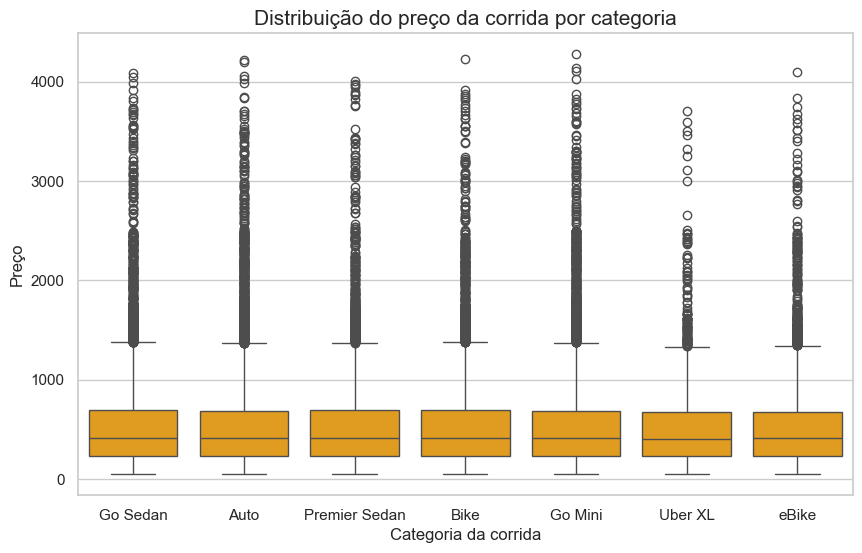

In [52]:
fig, ax = plt.subplots(figsize=(10,6))
sns.boxplot(x="Vehicle Type",
            y="Booking Value",
            data=df,
            color="orange",
            ax=ax)

ax.set_title("Distribuição do preço da corrida por categoria", fontsize=15)
ax.set_xlabel("Categoria da corrida")
ax.set_ylabel("Preço")
plt.show()


#### Preço e distância dentro de uma mesma categoria de veículo:

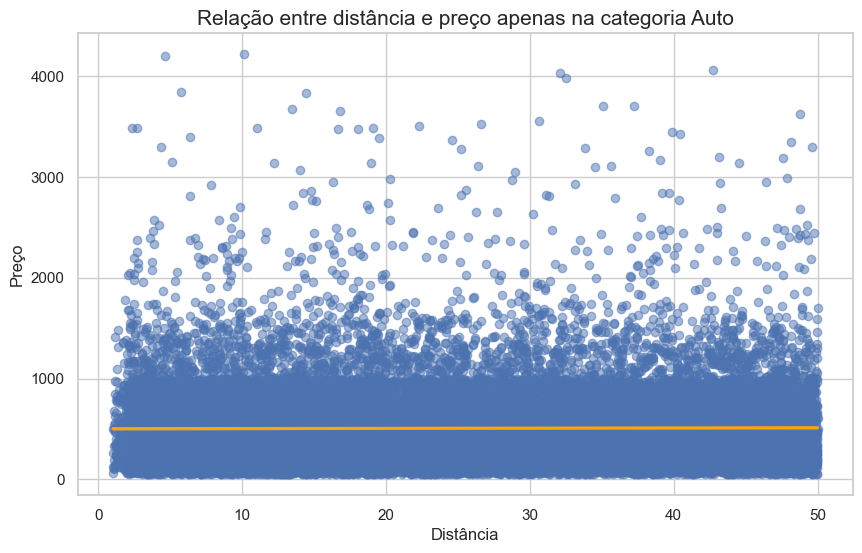

In [47]:
df['Vehicle Type'].value_counts()

df_type_auto = df[df['Vehicle Type'] == "Auto"]

fig, ax = plt.subplots(figsize=(10,6))
sns.regplot(x="Ride Distance",
            y="Booking Value",
            data=df_type_auto,
            scatter_kws={'alpha':0.5},
            line_kws={"color":"orange"},
            ax=ax)

ax.set_title("Relação entre distância e preço apenas na categoria Auto", fontsize=15)
ax.set_xlabel("Distância")
ax.set_ylabel("Preço")
plt.show()

#### Preço e mês do ano:

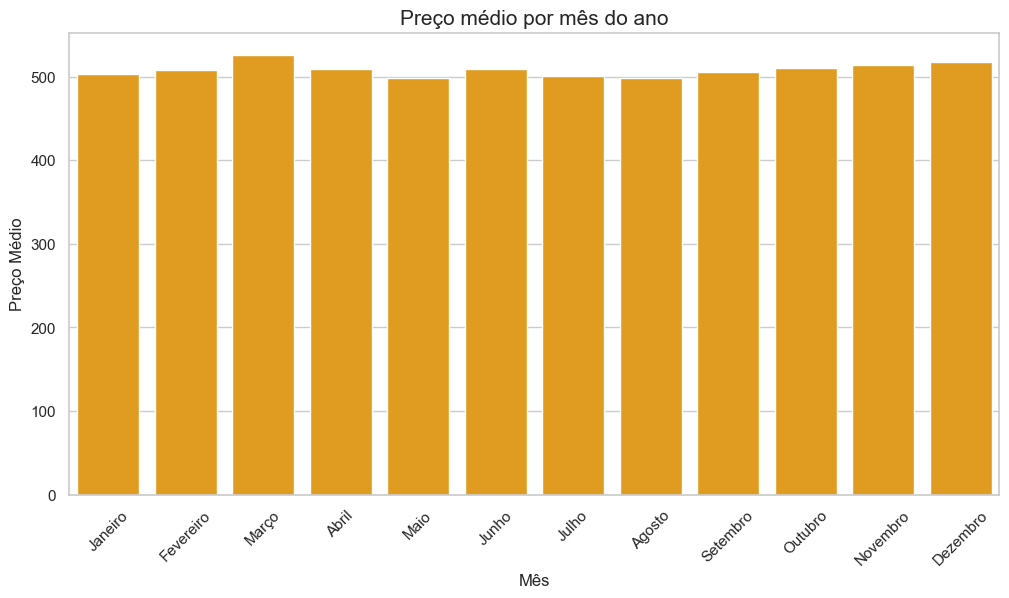

In [48]:
df['Month'] = df['Date'].dt.month_name(locale='pt_BR')

mean_price_by_month = df.groupby('Month')['Booking Value'].mean()

month_order = ["Janeiro", "Fevereiro", "Março", "Abril", "Maio", "Junho",
               "Julho", "Agosto", "Setembro", "Outubro", "Novembro", "Dezembro"]

mean_price_by_month = mean_price_by_month.reindex(month_order)

fig, ax = plt.subplots(figsize=(12,6))
sns.barplot(x=mean_price_by_month.index, 
            y=mean_price_by_month.values, 
            color="orange", 
            ax=ax)

ax.set_title("Preço médio por mês do ano", fontsize=15)
ax.set_xlabel("Mês")
ax.set_ylabel("Preço Médio")
plt.xticks(rotation=45)
plt.show()


#### Preço e localidade:

O último suspiro: localidade. Utilizei o preço mediano para evitar distorções de possíveis anomalias.

176
176


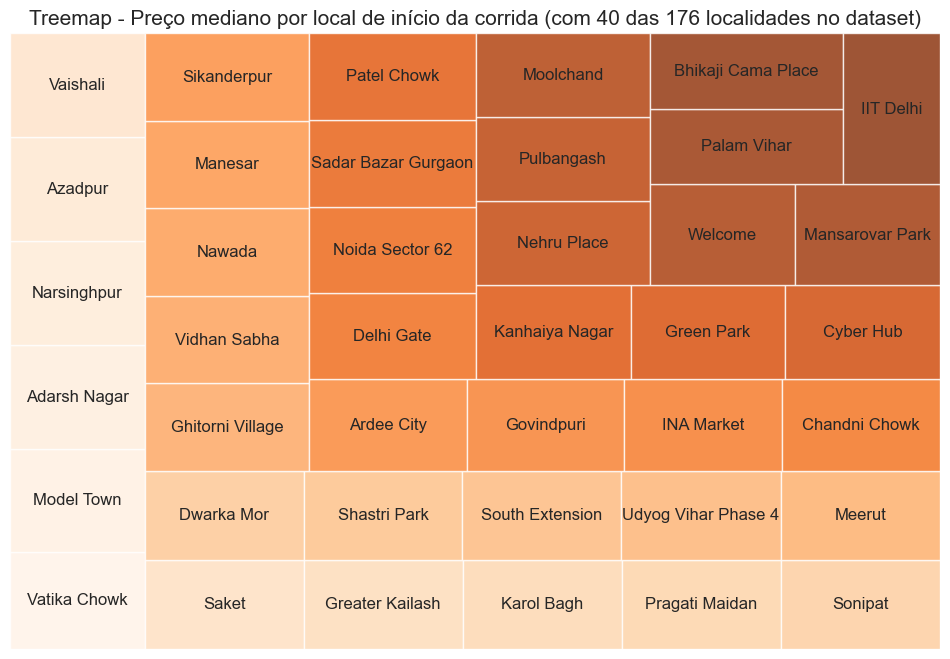

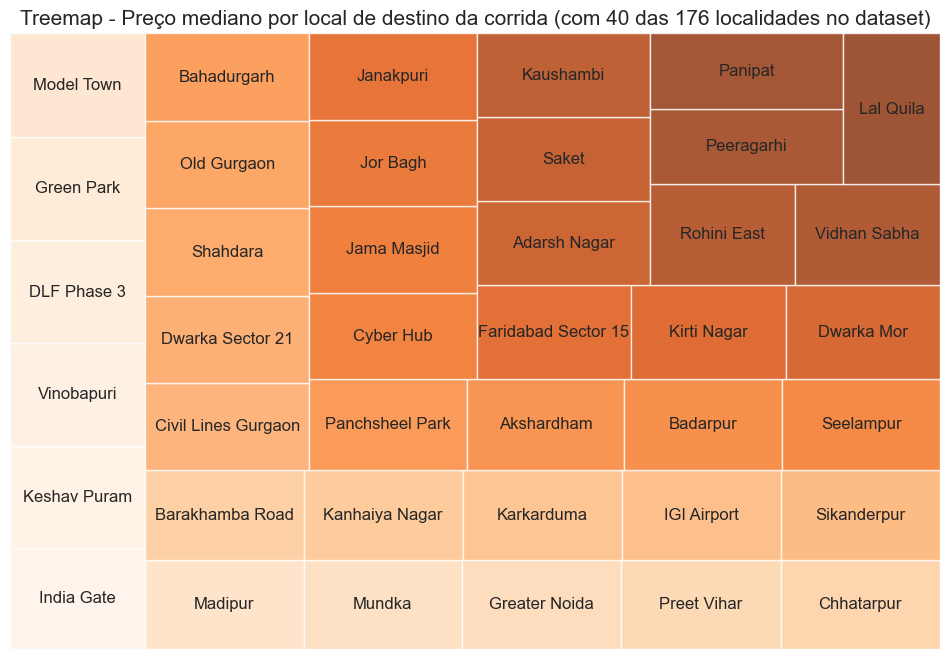

In [59]:
print (df['Drop Location'].nunique())
print (df['Pickup Location'].nunique())

import squarify

median_price_by_pickup = df.groupby('Pickup Location')['Booking Value'].median()
median_price_by_pickup = median_price_by_pickup.sort_values(ascending=True).head(40)

plt.figure(figsize=(12,8))
squarify.plot(sizes=median_price_by_pickup.values, 
              label=median_price_by_pickup.index, 
              color=sns.color_palette("Oranges", len(median_price_by_pickup)), 
              alpha=0.8)

plt.title("Treemap - Preço mediano por local de início da corrida (com 40 das 176 localidades no dataset)", fontsize=15)
plt.axis('off')
plt.show()

median_price_by_drop = df.groupby('Drop Location')['Booking Value'].median()
median_price_by_drop = median_price_by_drop.sort_values(ascending=True).head(40)

plt.figure(figsize=(12,8))
squarify.plot(sizes=median_price_by_drop.values, 
              label=median_price_by_drop.index, 
              color=sns.color_palette("Oranges", len(median_price_by_drop)), 
              alpha=0.8)

plt.title("Treemap - Preço mediano por local de destino da corrida (com 40 das 176 localidades no dataset)", fontsize=15)
plt.axis('off')
plt.show()




#### Preço e distância com uma mesma localidade de origem.

Localidade com maior mediana de preço: Okhla


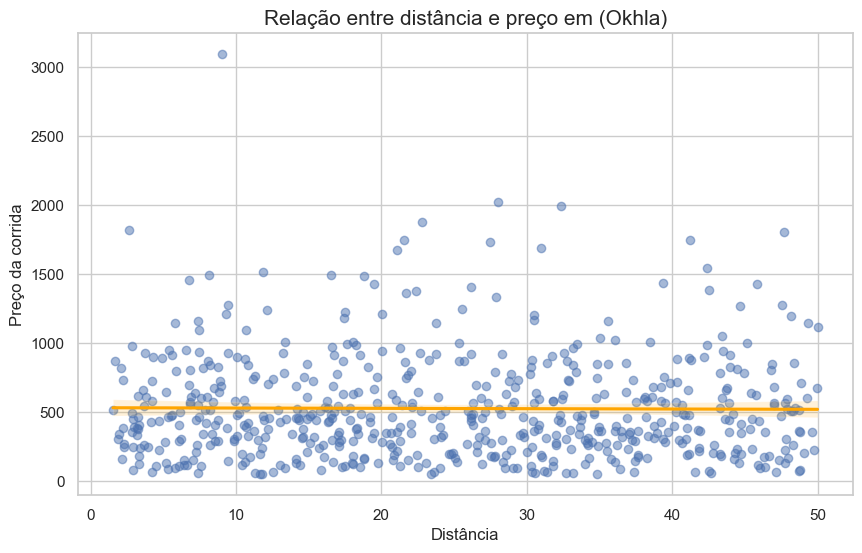

In [50]:
median_price_by_pickup = df.groupby('Pickup Location')['Booking Value'].median()
top_location = median_price_by_pickup.idxmax()
print("Localidade com maior mediana de preço:", top_location)

df_rich_location = df[df['Pickup Location'] == top_location]

fig, ax = plt.subplots(figsize=(10,6))
sns.regplot(x="Ride Distance",
            y="Booking Value",
            data=df_rich_location, 
            scatter_kws={'alpha':0.5},
            line_kws={"color":"orange"},
            ax=ax)

ax.set_title(f"Relação entre distância e preço em ({top_location})", fontsize=15)
ax.set_xlabel("Distância")
ax.set_ylabel("Preço da corrida")
plt.show()


